# Bent Lead Detector (single-defect notebook)

Notebook wykrywa tylko bent_lead (good vs bent_lead) na bazie Missing/Extra:
- Missing = M_ref \ M_test
- Extra = M_test \ M_ref

Finalna maska bent: union(Missing, Extra) po cleanup.

## Kolejnosc uruchamiania
1. Run All od gory.
2. W komorce demo zmien test_class i test_name.
3. Uruchom batch eval i diagnostyke.
4. Uruchom tuning progow, potem finalna walidacje.

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import model

# ===============================
# BENT LEAD - PARAMETRY
# ===============================
LEAD_ZONE_START = 0.68
EROSION_ITERATIONS = 2
MIN_COMPONENT_AREA = 25

# Logika strefowa (analogiczna do cut_lead, ale na Missing+Extra)
MIN_ZONE_MISSING_AREA = 450
MIN_ZONE_EXTRA_AREA = 450
MIN_ZONE_COMBINED_AREA = 1100
DECISION_MODE = "any"  # any | majority

# optional misplaced gate
USE_MISPLACED_GATE = True
MISPLACED_SHIFT_PX = 22.0

# alignment domyslnie OFF dla bent
USE_ALIGNMENT = False

PROJECT_ROOT = Path.cwd()
REFERENCE_MASK = np.load("reference_mask_vote_0.50.npy").astype(np.uint8)

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.titlesize'] = 10

print("Notebook ustawiony na bent_lead (single-defect, strefy ROI).")

Notebook ustawiony na bent_lead (single-defect, strefy ROI).


In [2]:
def load_rgb(image_path):
    bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f"Brak obrazu: {image_path}")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def cleanup_components(mask, min_area=MIN_COMPONENT_AREA):
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = np.zeros_like(mask)
    for i in range(1, n):
        if int(stats[i, cv2.CC_STAT_AREA]) >= int(min_area):
            out[labels == i] = 255
    return out

def ensure_binary(mask):
    if mask.dtype != np.uint8:
        mask = np.clip(mask, 0, 255).astype(np.uint8)
    return ((mask > 0).astype(np.uint8) * 255)

def get_alignment_params(ref_mask, test_mask):
    h, _ = ref_mask.shape
    roi_h = int(h * 0.5)
    ref_top = ref_mask[:roi_h, :]
    test_top = test_mask[:roi_h, :]

    M_ref = cv2.moments(ref_top)
    M_test = cv2.moments(test_top)
    if M_ref['m00'] == 0 or M_test['m00'] == 0:
        return 0, 0

    dx = int(M_ref['m10'] / M_ref['m00'] - M_test['m10'] / M_test['m00'])
    dy = int(M_ref['m01'] / M_ref['m00'] - M_test['m01'] / M_test['m00'])
    return dx, dy

def align_image(mask, dx, dy):
    rows, cols = mask.shape[:2]
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    return cv2.warpAffine(mask, M, (cols, rows), flags=cv2.INTER_NEAREST)

def compute_lead_zones(ref_mask, lead_zone_start=LEAD_ZONE_START):
    ys, xs = np.where(ref_mask > 0)
    if xs.size == 0:
        raise ValueError('Maska referencyjna jest pusta.')

    h, w = ref_mask.shape
    y0 = int(np.clip(int(h * lead_zone_start), 0, h - 1))
    x_min = int(xs.min())
    x_max = int(xs.max())
    if x_max <= x_min:
        raise ValueError('Niepoprawny zakres X maski referencyjnej.')

    width = x_max - x_min + 1
    t1 = x_min + width // 3
    t2 = x_min + (2 * width) // 3

    zones = {
        'left': (x_min, t1),
        'center': (t1, t2),
        'right': (t2, x_max + 1),
    }

    clipped = {}
    for name, (xa, xb) in zones.items():
        xa = int(np.clip(xa, 0, w))
        xb = int(np.clip(xb, 0, w))
        if xb <= xa:
            xb = min(w, xa + 1)
        clipped[name] = (xa, xb)

    return y0, clipped

def extract_core_mask(mask, erosion_ratio=0.04):
    m = ensure_binary(mask)
    h, w = m.shape
    k = int(round(min(h, w) * erosion_ratio))
    k = max(3, min(31, k))
    if k % 2 == 0:
        k += 1
    kernel = np.ones((k, k), np.uint8)
    core = cv2.erode(m, kernel, iterations=1)
    if np.count_nonzero(core) == 0:
        return m
    return core

def centroid(mask):
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return None
    return float(xs.mean()), float(ys.mean())

def centroid_distance(mask_a, mask_b):
    ca = centroid(mask_a)
    cb = centroid(mask_b)
    if ca is None or cb is None:
        return 0.0
    return float(np.hypot(ca[0] - cb[0], ca[1] - cb[1]))

In [3]:
def compute_missing_extra_masks(ref_mask, test_mask):
    ref_b = ensure_binary(ref_mask)
    test_b = ensure_binary(test_mask)

    if ref_b.shape != test_b.shape:
        h, w = test_b.shape
        ref_b = cv2.resize(ref_b, (w, h), interpolation=cv2.INTER_NEAREST)

    ref_bin = ref_b > 0
    test_bin = test_b > 0

    missing = np.logical_and(ref_bin, np.logical_not(test_bin)).astype(np.uint8) * 255
    extra = np.logical_and(test_bin, np.logical_not(ref_bin)).astype(np.uint8) * 255

    ref_px = int(np.count_nonzero(ref_bin))
    missing_px = int(np.count_nonzero(missing))
    extra_px = int(np.count_nonzero(extra))

    denom = float(max(ref_px, 1))
    missing_ratio = missing_px / denom
    extra_ratio = extra_px / denom
    total_change_ratio = (missing_px + extra_px) / denom

    return {
        'missing': missing.astype(np.uint8),
        'extra': extra.astype(np.uint8),
        'missing_px': missing_px,
        'extra_px': extra_px,
        'missing_ratio': float(missing_ratio),
        'extra_ratio': float(extra_ratio),
        'total_change_ratio': float(total_change_ratio),
    }

def zone_stats(mask, zones, y0):
    stats = {}
    for zone_name, (x0, x1) in zones.items():
        z = mask[y0:, x0:x1]
        stats[zone_name] = int(np.count_nonzero(z))
    return stats

def zone_dominance(zdict):
    vals = np.array([zdict['left'], zdict['center'], zdict['right']], dtype=np.float32)
    s = float(vals.sum())
    if s <= 0:
        return 0.0
    return float(vals.max() / s)

In [16]:
def detect_bent_lead(
    test_img_rgb,
    ref_mask,
    use_alignment=USE_ALIGNMENT,
    use_misplaced_gate=USE_MISPLACED_GATE,
    misplaced_shift_px=MISPLACED_SHIFT_PX,
    erosion_iterations=EROSION_ITERATIONS,
    min_zone_missing_area=MIN_ZONE_MISSING_AREA,
    min_zone_extra_area=MIN_ZONE_EXTRA_AREA,
    min_zone_combined_area=MIN_ZONE_COMBINED_AREA,
    decision_mode=DECISION_MODE,
    min_component_area=MIN_COMPONENT_AREA,
    return_debug=True,
):
    test_mask = model._extract_transistor_mask(test_img_rgb)
    work_mask = test_mask.copy()

    if use_alignment:
        dx, dy = get_alignment_params(ref_mask, test_mask)
        work_mask = align_image(test_mask, dx, dy)
    else:
        dx, dy = 0, 0

    if work_mask.shape != ref_mask.shape:
        h, w = ref_mask.shape
        work_mask = cv2.resize(work_mask, (w, h), interpolation=cv2.INTER_NEAREST)

    y0, zones = compute_lead_zones(ref_mask, lead_zone_start=LEAD_ZONE_START)

    core_ref = extract_core_mask(ref_mask)
    core_test = extract_core_mask(work_mask)
    shift_px = centroid_distance(core_ref, core_test)

    # Misplaced gate: gdy przesuniecie globalne duze, nie klasyfikujemy jako bent.
    if use_misplaced_gate and shift_px > float(misplaced_shift_px):
        zero_mask = np.zeros_like(ref_mask, dtype=np.uint8)
        result = {
            'is_bent': False,
            'pred_label': 'not_bent_misplaced_gate',
            'dx': dx,
            'dy': dy,
            'shift_px': float(shift_px),
            'missing_ratio': 0.0,
            'extra_ratio': 0.0,
            'total_change_ratio': 0.0,
            'bent_mask': zero_mask,
            'missing': zero_mask.copy(),
            'extra': zero_mask.copy(),
            'zones': zones,
            'y0': y0,
            'missing_zone': {'left': 0, 'center': 0, 'right': 0},
            'extra_zone': {'left': 0, 'center': 0, 'right': 0},
            'combined_zone': {'left': 0, 'center': 0, 'right': 0},
            'zone_flags': {'left': False, 'center': False, 'right': False},
            'zone_thresholds': {
                'missing': int(min_zone_missing_area),
                'extra': int(min_zone_extra_area),
                'combined': int(min_zone_combined_area),
            },
            'decision_mode': decision_mode,
        }
        if return_debug:
            result['test_mask'] = test_mask
            result['work_mask'] = work_mask
        return result

    kernel = np.ones((3, 3), np.uint8)
    ref_leads = ensure_binary(ref_mask[y0:, :])
    test_leads = ensure_binary(work_mask[y0:, :])

    ref_eroded = cv2.erode(ref_leads, kernel, iterations=int(erosion_iterations))
    test_eroded = cv2.erode(test_leads, kernel, iterations=int(erosion_iterations))

    # Missing: co zniknelo wzgledem referencji
    missing_lead = cv2.subtract(ref_eroded, test_leads)
    # Extra: co doszlo wzgledem referencji
    extra_lead = cv2.subtract(test_eroded, ref_leads)

    missing_lead = cv2.morphologyEx(missing_lead, cv2.MORPH_OPEN, kernel)
    extra_lead = cv2.morphologyEx(extra_lead, cv2.MORPH_OPEN, kernel)
    missing_lead = cleanup_components(missing_lead, min_area=min_component_area)
    extra_lead = cleanup_components(extra_lead, min_area=min_component_area)

    # Pelnowymiarowe mapy do debugu i wizualizacji
    missing = np.zeros_like(ref_mask, dtype=np.uint8)
    extra = np.zeros_like(ref_mask, dtype=np.uint8)
    missing[y0:, :] = missing_lead
    extra[y0:, :] = extra_lead

    missing_zone = {}
    extra_zone = {}
    combined_zone = {}
    zone_flags = {}

    for zone_name, (x0, x1) in zones.items():
        zm = missing[y0:, x0:x1]
        ze = extra[y0:, x0:x1]
        cm = int(np.count_nonzero(zm))
        ce = int(np.count_nonzero(ze))
        cc = cm + ce

        missing_zone[zone_name] = cm
        extra_zone[zone_name] = ce
        combined_zone[zone_name] = cc

        both_present = (cm >= int(min_zone_missing_area)) and (ce >= int(min_zone_extra_area))
        strong_single = (
            cc >= int(1.6 * min_zone_combined_area) and
            max(cm, ce) >= max(int(min_zone_missing_area), int(min_zone_extra_area))
        )
        zone_flags[zone_name] = bool((cc >= int(min_zone_combined_area) and both_present) or strong_single)

    if decision_mode == "any":
        is_bent = bool(zone_flags['left'] or zone_flags['center'] or zone_flags['right'])
    elif decision_mode == "majority":
        is_bent = int(zone_flags['left']) + int(zone_flags['center']) + int(zone_flags['right']) >= 2
    else:
        raise ValueError(f"Nieobslugiwany decision_mode: {decision_mode}")

    bent_mask = cv2.bitwise_or(missing, extra)
    support = cv2.bitwise_or(ensure_binary(ref_mask), ensure_binary(work_mask))
    support = cv2.dilate(support, np.ones((9, 9), np.uint8), iterations=1)
    bent_mask = cv2.bitwise_and(bent_mask, support)
    bent_mask = cv2.morphologyEx(bent_mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    bent_mask = cleanup_components(bent_mask, min_area=min_component_area).astype(np.uint8)

    if not is_bent:
        bent_mask = np.zeros_like(bent_mask, dtype=np.uint8)

    ref_px = int(np.count_nonzero(ensure_binary(ref_mask)))
    missing_px = int(np.count_nonzero(missing))
    extra_px = int(np.count_nonzero(extra))
    denom = float(max(ref_px, 1))

    result = {
        'is_bent': bool(is_bent),
        'pred_label': 'bent_lead' if is_bent else 'good_or_other',
        'dx': dx,
        'dy': dy,
        'shift_px': float(shift_px),
        'missing_ratio': float(missing_px / denom),
        'extra_ratio': float(extra_px / denom),
        'total_change_ratio': float((missing_px + extra_px) / denom),
        'missing_px': missing_px,
        'extra_px': extra_px,
        'bent_mask': bent_mask,
        'missing': missing,
        'extra': extra,
        'zones': zones,
        'y0': y0,
        'missing_zone': missing_zone,
        'extra_zone': extra_zone,
        'combined_zone': combined_zone,
        'zone_flags': zone_flags,
        'zone_thresholds': {
            'missing': int(min_zone_missing_area),
            'extra': int(min_zone_extra_area),
            'combined': int(min_zone_combined_area),
        },
        'decision_mode': decision_mode,
    }

    if return_debug:
        result['test_mask'] = test_mask
        result['work_mask'] = work_mask

    return result

In [14]:
def _draw_zone_lines(ax, y0, zones):
    colors = {'left': 'lime', 'center': 'cyan', 'right': 'yellow'}
    for zone_name, (x0, x1) in zones.items():
        ax.axvline(x=x0, color=colors[zone_name], linestyle='--', linewidth=1)
        ax.axvline(x=x1, color=colors[zone_name], linestyle='--', linewidth=1)
    ax.axhline(y=y0, color='orange', linestyle=':', linewidth=1)

def print_bent_table(result):
    print('Bent Summary')
    print(f"  pred_label={result['pred_label']} | is_bent={result['is_bent']}")
    print(f"  missing_ratio={result['missing_ratio']:.4f} extra_ratio={result['extra_ratio']:.4f} total={result['total_change_ratio']:.4f}")
    print(f"  shift_px={result['shift_px']:.2f} | decision_mode={result['decision_mode']}")
    zthr = result['zone_thresholds']
    print(f"  thresholds: missing>={zthr['missing']} extra>={zthr['extra']} combined>={zthr['combined']}")
    for z in ['left', 'center', 'right']:
        print(
            f"  {z:6s} | missing={result['missing_zone'][z]:5d} | "
            f"extra={result['extra_zone'][z]:5d} | combined={result['combined_zone'][z]:5d} | "
            f"flag={result['zone_flags'][z]}"
        )

def visualize_bent_result(img_rgb, ref_mask, result):
    y0 = result['y0']
    zones = result['zones']

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))

    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title(f"Orig | {result['pred_label']}")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(ref_mask, cmap='gray')
    _draw_zone_lines(axes[0, 1], y0, zones)
    axes[0, 1].set_title('Reference mask + zones')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(result['work_mask'], cmap='gray')
    _draw_zone_lines(axes[0, 2], y0, zones)
    axes[0, 2].set_title('Test mask (work)')
    axes[0, 2].axis('off')

    axes[0, 3].imshow(result['bent_mask'], cmap='hot')
    _draw_zone_lines(axes[0, 3], y0, zones)
    axes[0, 3].set_title('Final bent mask')
    axes[0, 3].axis('off')

    axes[1, 0].imshow(result['missing'], cmap='hot')
    _draw_zone_lines(axes[1, 0], y0, zones)
    axes[1, 0].set_title('Missing')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(result['extra'], cmap='hot')
    _draw_zone_lines(axes[1, 1], y0, zones)
    axes[1, 1].set_title('Extra')
    axes[1, 1].axis('off')

    for i, zone_name in enumerate(['left', 'center', 'right']):
        x0, x1 = zones[zone_name]
        zmiss = result['missing'][y0:, x0:x1]
        zextra = result['extra'][y0:, x0:x1]
        z = cv2.bitwise_or(zmiss, zextra)
        ax = axes[1, i+1] if i < 2 else axes[1, 3]
        ax.imshow(z, cmap='hot')
        ax.set_title(
            f"{zone_name}: M={result['missing_zone'][zone_name]} "
            f"E={result['extra_zone'][zone_name]} C={result['combined_zone'][zone_name]} "
            f"F={result['zone_flags'][zone_name]}"
        )
        ax.axis('off')

    plt.tight_layout()
    plt.show()

Plik: 000.png | Klasa folderu: bent_lead
Bent Summary
  pred_label=bent_lead | is_bent=True
  missing_ratio=0.1746 extra_ratio=0.0728 total=0.2474
  shift_px=6.96 cut_like=False
  left   | missing= 1696 | extra= 9389
  center | missing= 1684 | extra=   24
  right  | missing= 1919 | extra=  296


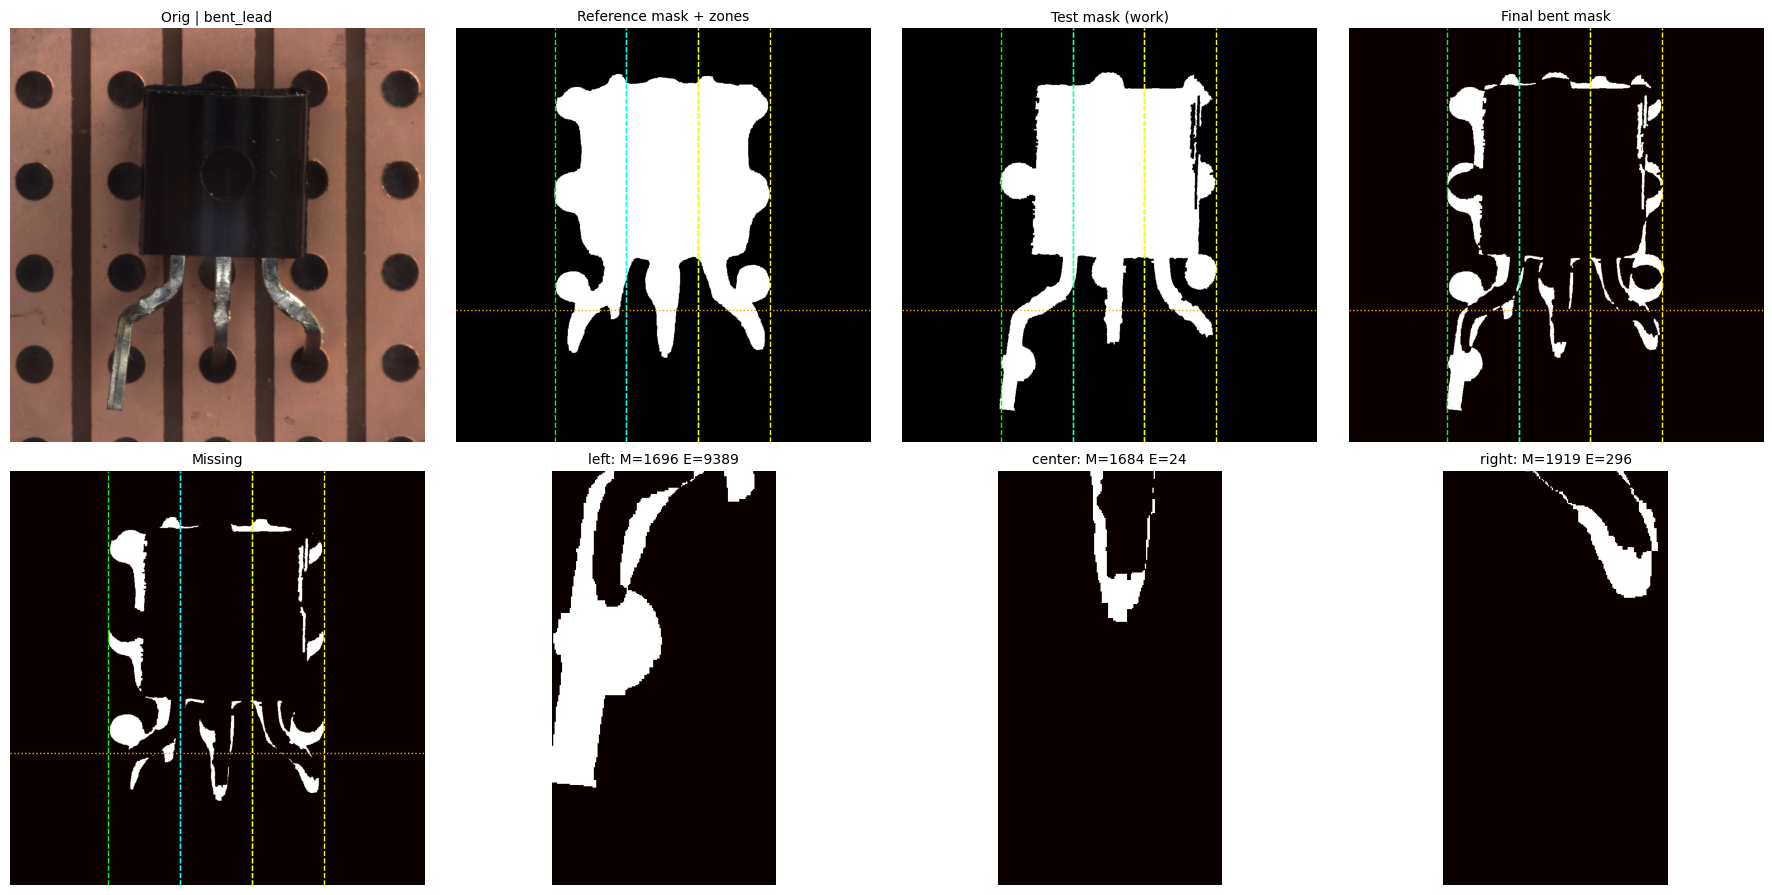

In [6]:
# DEMO: pojedynczy obraz
test_class = 'bent_lead'   # np. good / bent_lead / cut_lead / misplaced
test_name = '000.png'

test_path = PROJECT_ROOT / 'transistor' / 'test' / test_class / test_name
test_img = load_rgb(test_path)

demo_result = detect_bent_lead(
    test_img,
    REFERENCE_MASK,
    use_alignment=USE_ALIGNMENT,
    use_misplaced_gate=USE_MISPLACED_GATE,
    return_debug=True,
)

print(f"Plik: {test_path.name} | Klasa folderu: {test_class}")
print_bent_table(demo_result)
visualize_bent_result(test_img, REFERENCE_MASK, demo_result)

In [17]:
# BATCH EVAL: bent_lead vs reszta
def iter_class_files(class_name):
    folder = PROJECT_ROOT / 'transistor' / 'test' / class_name
    return sorted(folder.glob('*.png'))

def evaluate_bent(all_classes=None, limits=None, config=None):
    if all_classes is None:
        all_classes = ['good', 'bent_lead', 'cut_lead', 'damaged_case', 'misplaced']

    if limits is None:
        limits = {}

    if config is None:
        config = {
            'erosion_iterations': EROSION_ITERATIONS,
            'min_zone_missing_area': MIN_ZONE_MISSING_AREA,
            'min_zone_extra_area': MIN_ZONE_EXTRA_AREA,
            'min_zone_combined_area': MIN_ZONE_COMBINED_AREA,
            'decision_mode': DECISION_MODE,
            'use_alignment': USE_ALIGNMENT,
            'use_misplaced_gate': USE_MISPLACED_GATE,
            'misplaced_shift_px': MISPLACED_SHIFT_PX,
            'min_component_area': MIN_COMPONENT_AREA,
        }

    rows = []
    for class_name in all_classes:
        files = iter_class_files(class_name)
        lim = limits.get(class_name)
        if lim is not None:
            files = files[:lim]

        for p in files:
            img = load_rgb(p)
            res = detect_bent_lead(
                img,
                REFERENCE_MASK,
                use_alignment=config['use_alignment'],
                use_misplaced_gate=config['use_misplaced_gate'],
                misplaced_shift_px=config['misplaced_shift_px'],
                erosion_iterations=config['erosion_iterations'],
                min_zone_missing_area=config['min_zone_missing_area'],
                min_zone_extra_area=config['min_zone_extra_area'],
                min_zone_combined_area=config['min_zone_combined_area'],
                decision_mode=config['decision_mode'],
                min_component_area=config['min_component_area'],
                return_debug=False,
            )

            rows.append({
                'class_name': class_name,
                'file_name': p.name,
                'pred': bool(res['is_bent']),
                'gt': class_name == 'bent_lead',
                'pred_label': res['pred_label'],
                'missing_ratio': res['missing_ratio'],
                'extra_ratio': res['extra_ratio'],
                'total_change_ratio': res['total_change_ratio'],
                'shift_px': res['shift_px'],
                'left_flag': res['zone_flags']['left'],
                'center_flag': res['zone_flags']['center'],
                'right_flag': res['zone_flags']['right'],
            })

    return rows

def summarize_rows(rows, verbose=True):
    tp = sum(1 for r in rows if r['gt'] and r['pred'])
    tn = sum(1 for r in rows if (not r['gt']) and (not r['pred']))
    fp = sum(1 for r in rows if (not r['gt']) and r['pred'])
    fn = sum(1 for r in rows if r['gt'] and (not r['pred']))

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    tnr = tn / max(tn + fp, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)
    balanced = 0.5 * (recall + tnr)

    if verbose:
        print(f"TP={tp} TN={tn} FP={fp} FN={fn}")
        print(f"precision={precision:.3f} recall={recall:.3f} tnr={tnr:.3f} f1={f1:.3f} balanced={balanced:.3f}")

    return {
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
        'precision': precision, 'recall': recall, 'tnr': tnr,
        'f1': f1, 'balanced': balanced,
    }

rows_quick = evaluate_bent(limits={'good': 20})
metrics_quick = summarize_rows(rows_quick, verbose=True)

TP=4 TN=33 FP=14 FN=5
precision=0.222 recall=0.444 tnr=0.702 f1=0.296 balanced=0.573


In [18]:
# DIAGNOSTYKA + GRID SEARCH (strefowy, podobny stylem do cut_lead)
def print_feature_stats(rows):
    for cls in ['good', 'bent_lead', 'cut_lead', 'damaged_case', 'misplaced']:
        subset = [r for r in rows if r['class_name'] == cls]
        if not subset:
            continue
        mr = np.array([r['missing_ratio'] for r in subset], dtype=np.float32)
        er = np.array([r['extra_ratio'] for r in subset], dtype=np.float32)
        tr = np.array([r['total_change_ratio'] for r in subset], dtype=np.float32)
        print(f"\nKlasa={cls}")
        print(f"  missing  min={mr.min():.4f} max={mr.max():.4f} mean={mr.mean():.4f}")
        print(f"  extra    min={er.min():.4f} max={er.max():.4f} mean={er.mean():.4f}")
        print(f"  total    min={tr.min():.4f} max={tr.max():.4f} mean={tr.mean():.4f}")

def grid_search_bent(limits=None):
    if limits is None:
        # szybszy tuning: ograniczamy tylko good, bent i cut idzie cale
        limits = {'good': 25}

    miss_vals = [250, 450, 700]
    extra_vals = [250, 450, 700]
    comb_vals = [900, 1100, 1400]

    out = []
    total_cfg = len(miss_vals) * len(extra_vals) * len(comb_vals)
    i = 0

    for mthr in miss_vals:
        for ethr in extra_vals:
            for cthr in comb_vals:
                i += 1
                cfg = {
                    'erosion_iterations': EROSION_ITERATIONS,
                    'min_zone_missing_area': mthr,
                    'min_zone_extra_area': ethr,
                    'min_zone_combined_area': cthr,
                    'decision_mode': DECISION_MODE,
                    'use_alignment': USE_ALIGNMENT,
                    'use_misplaced_gate': USE_MISPLACED_GATE,
                    'misplaced_shift_px': MISPLACED_SHIFT_PX,
                    'min_component_area': MIN_COMPONENT_AREA,
                }

                rows = evaluate_bent(config=cfg, limits=limits)
                m = summarize_rows(rows, verbose=False)

                fp_good = sum(1 for r in rows if r['class_name'] == 'good' and r['pred'])
                out.append({
                    'min_zone_missing_area': mthr,
                    'min_zone_extra_area': ethr,
                    'min_zone_combined_area': cthr,
                    'f1': m['f1'],
                    'balanced': m['balanced'],
                    'precision': m['precision'],
                    'recall': m['recall'],
                    'fp_good': fp_good,
                    'fp': m['fp'],
                    'fn': m['fn'],
                })

                if i % 5 == 0 or i == total_cfg:
                    print(f"Progress: {i}/{total_cfg}")

    out = sorted(out, key=lambda r: (r['f1'], r['balanced'], -r['fp_good']), reverse=True)
    print('Top 10 config:')
    for r in out[:10]:
        print(r)
    return out

print_feature_stats(rows_quick)
grid_results = grid_search_bent()
best_config = grid_results[0]
print('\nBest config:', best_config)


Klasa=good
  missing  min=0.0000 max=0.0199 mean=0.0067
  extra    min=0.0000 max=0.0373 mean=0.0070
  total    min=0.0000 max=0.0550 mean=0.0137

Klasa=bent_lead
  missing  min=0.0000 max=0.0294 mean=0.0092
  extra    min=0.0000 max=0.0417 mean=0.0130
  total    min=0.0000 max=0.0602 mean=0.0222

Klasa=cut_lead
  missing  min=0.0000 max=0.0000 mean=0.0000
  extra    min=0.0000 max=0.0000 mean=0.0000
  total    min=0.0000 max=0.0000 mean=0.0000

Klasa=damaged_case
  missing  min=0.0000 max=0.0250 mean=0.0071
  extra    min=0.0000 max=0.0223 mean=0.0048
  total    min=0.0000 max=0.0474 mean=0.0120

Klasa=misplaced
  missing  min=0.0000 max=0.0494 mean=0.0110
  extra    min=0.0000 max=0.0000 mean=0.0000
  total    min=0.0000 max=0.0494 mean=0.0110
Progress: 5/27
Progress: 10/27
Progress: 15/27
Progress: 20/27
Progress: 25/27
Progress: 27/27
Top 10 config:
{'min_zone_missing_area': 250, 'min_zone_extra_area': 700, 'min_zone_combined_area': 1400, 'f1': 0.32, 'balanced': 0.6068376068376069

TP=4 TN=55 FP=22 FN=5
precision=0.154 recall=0.444 tnr=0.714 f1=0.229 balanced=0.579

False positives: ['good/003.png', 'good/004.png', 'good/006.png', 'good/008.png', 'good/010.png', 'good/012.png', 'good/014.png', 'good/027.png', 'good/031.png', 'good/032.png', 'good/033.png', 'good/034.png', 'good/036.png', 'good/043.png', 'good/046.png', 'good/047.png', 'good/048.png', 'damaged_case/000.png', 'damaged_case/006.png', 'damaged_case/007.png', 'misplaced/002.png', 'misplaced/003.png']
False negatives: ['bent_lead/001.png', 'bent_lead/002.png', 'bent_lead/004.png', 'bent_lead/006.png', 'bent_lead/007.png']

Ustaw te wartosci jako default na gorze notebooka:
{'erosion_iterations': 2, 'min_zone_missing_area': 250, 'min_zone_extra_area': 700, 'min_zone_combined_area': 1400, 'decision_mode': 'any', 'use_alignment': False, 'use_misplaced_gate': True, 'misplaced_shift_px': 22.0, 'min_component_area': 25}
Plik: 003.png
Sciezka: c:\Coding\Sem_6\ZAW\CWP\Transformers\proj01\transistor\test\bent_l

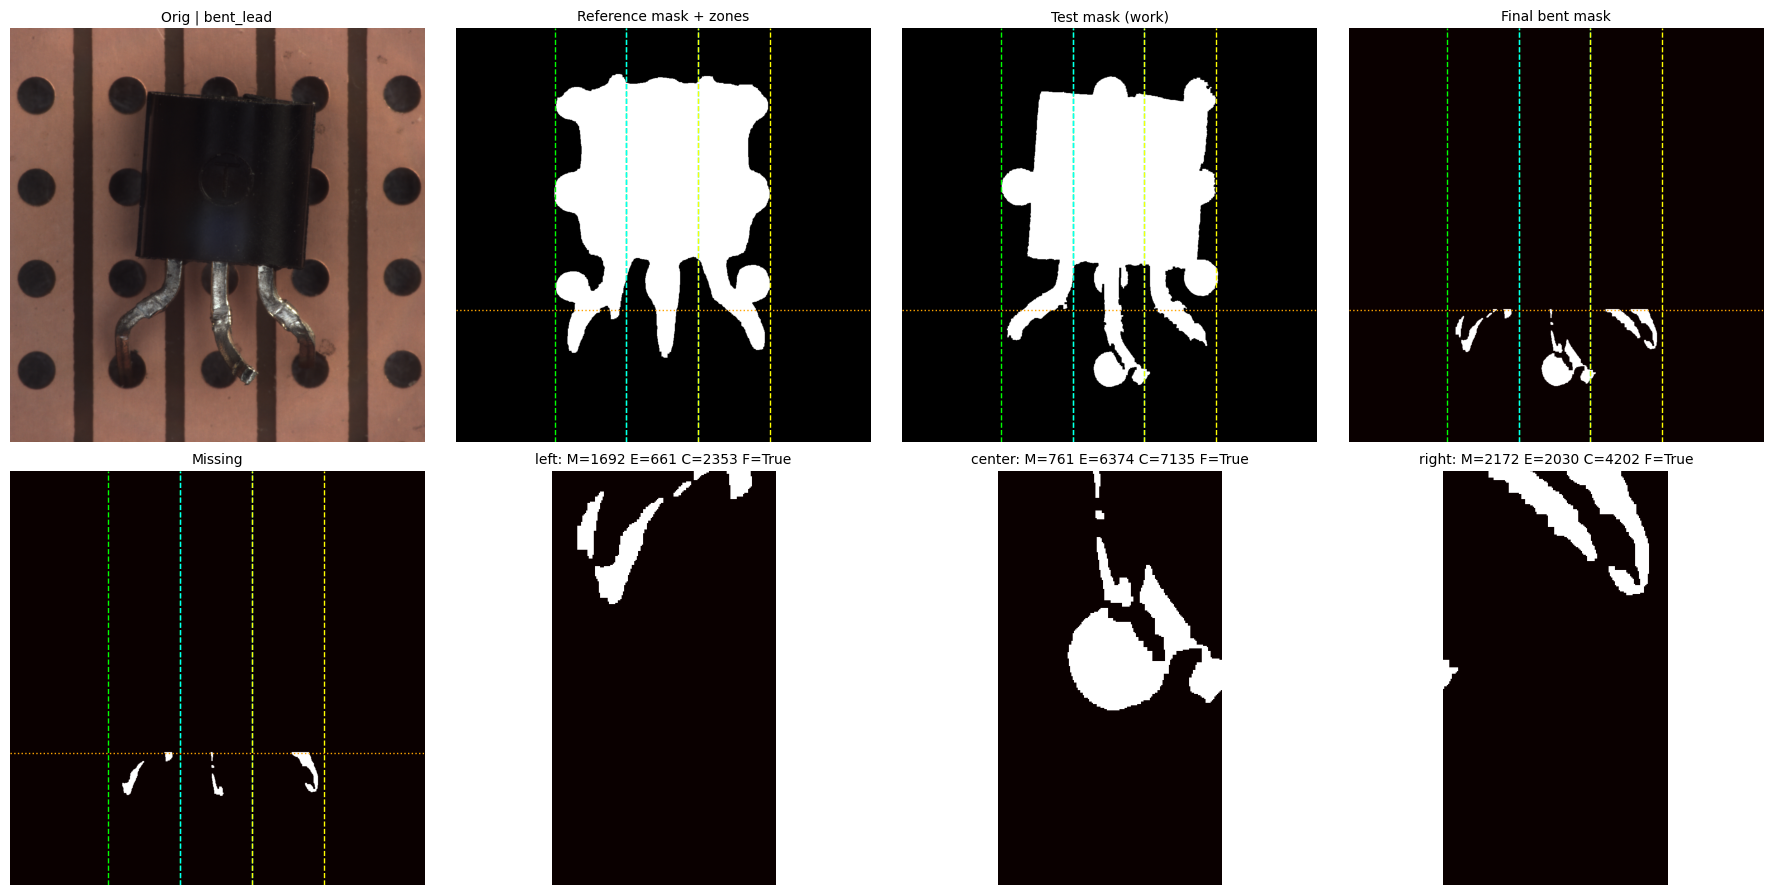

In [19]:
# FINALNA WALIDACJA + klasyfikacja 1 pliku
final_cfg = {
    'erosion_iterations': EROSION_ITERATIONS,
    'min_zone_missing_area': best_config['min_zone_missing_area'],
    'min_zone_extra_area': best_config['min_zone_extra_area'],
    'min_zone_combined_area': best_config['min_zone_combined_area'],
    'decision_mode': DECISION_MODE,
    'use_alignment': USE_ALIGNMENT,
    'use_misplaced_gate': USE_MISPLACED_GATE,
    'misplaced_shift_px': MISPLACED_SHIFT_PX,
    'min_component_area': MIN_COMPONENT_AREA,
}

rows_final = evaluate_bent(config=final_cfg)
metrics_final = summarize_rows(rows_final, verbose=True)

fp_files = [f"{r['class_name']}/{r['file_name']}" for r in rows_final if (not r['gt']) and r['pred']]
fn_files = [f"{r['class_name']}/{r['file_name']}" for r in rows_final if r['gt'] and (not r['pred'])]

print('\nFalse positives:', fp_files if fp_files else 'brak')
print('False negatives:', fn_files if fn_files else 'brak')
print('\nUstaw te wartosci jako default na gorze notebooka:')
print(final_cfg)

DEFAULT_CLASSIFY_CFG = final_cfg.copy()

def resolve_input_image(file_name, class_name=None):
    direct = Path(file_name)
    if direct.exists():
        return direct

    test_root = PROJECT_ROOT / 'transistor' / 'test'
    if class_name is not None:
        candidate = test_root / class_name / file_name
        if candidate.exists():
            return candidate
        raise FileNotFoundError(f"Nie znaleziono pliku: {candidate}")

    matches = sorted(test_root.glob(f"**/{file_name}"))
    if not matches:
        raise FileNotFoundError(f"Nie znaleziono pliku {file_name} w {test_root}")
    if len(matches) > 1:
        print('Uwaga: wiele plikow o tej nazwie, uzywam pierwszego:')
        for m in matches:
            print(f"  - {m.relative_to(test_root)}")
    return matches[0]

def classify_one_image(file_name, class_name=None, config=None, show_plot=True):
    if config is None:
        config = DEFAULT_CLASSIFY_CFG

    image_path = resolve_input_image(file_name, class_name=class_name)
    img = load_rgb(image_path)

    res = detect_bent_lead(
        img,
        REFERENCE_MASK,
        use_alignment=config['use_alignment'],
        use_misplaced_gate=config['use_misplaced_gate'],
        misplaced_shift_px=config['misplaced_shift_px'],
        erosion_iterations=config['erosion_iterations'],
        min_zone_missing_area=config['min_zone_missing_area'],
        min_zone_extra_area=config['min_zone_extra_area'],
        min_zone_combined_area=config['min_zone_combined_area'],
        decision_mode=config['decision_mode'],
        min_component_area=config['min_component_area'],
        return_debug=True,
    )

    print(f"Plik: {image_path.name}")
    print(f"Sciezka: {image_path}")
    print(f"Predykcja: {res['pred_label']}")
    print_bent_table(res)

    if show_plot:
        visualize_bent_result(img, REFERENCE_MASK, res)

    return res['pred_label'], res

# Przyklad:
pred_label, pred_result = classify_one_image('003.png', class_name='bent_lead')